# FactoryMind AI — Visual Anomaly Baseline

This notebook establishes the first leakage-safe visual anomaly baseline for the MVTec AD **zipper** category. It uses a frozen ImageNet-pretrained ResNet18, spatial patch embeddings, a normal-only nearest-reference memory, image-level anomaly scoring, and spatial anomaly maps.

This is a research baseline—not a production model. No CNN training or fine-tuning occurs, anomaly scores are not probabilities, and the official test set is used only once after all development decisions are frozen.

In [1]:
from pathlib import Path
from time import perf_counter
import platform, random

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
import sklearn
from sklearn.metrics import (average_precision_score, confusion_matrix, f1_score,
                             precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
import torch
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision.models import ResNet18_Weights, resnet18
from torchvision.transforms import InterpolationMode
from torchvision.transforms import v2

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CATEGORY_ROOT = PROJECT_ROOT / 'data' / 'raw' / 'mvtec_ad' / 'zipper'
print({'python': platform.python_version(), 'torch': torch.__version__, 'torchvision': torchvision.__version__,
       'numpy': np.__version__, 'sklearn': sklearn.__version__, 'matplotlib': matplotlib.__version__,
       'device': str(DEVICE), 'mps_built': torch.backends.mps.is_built(), 'mps_available': torch.backends.mps.is_available()})

{'python': '3.13.2', 'torch': '2.13.0', 'torchvision': '0.28.0', 'numpy': '2.5.2', 'sklearn': '1.9.0', 'matplotlib': '3.11.1', 'device': 'mps', 'mps_built': True, 'mps_available': True}


## 1. Dataset Validation

The structure and counts must match Notebook 14 before feature extraction begins. Every anomalous test image must map to its official ground-truth mask. Raw files are read only.

In [2]:
def pngs(path): return sorted(path.glob('*.png'))
required = [CATEGORY_ROOT / 'train' / 'good', CATEGORY_ROOT / 'test' / 'good', CATEGORY_ROOT / 'ground_truth']
missing = [str(path) for path in required if not path.is_dir()]
if missing: raise FileNotFoundError(f'Missing required zipper directories: {missing}')

train_good_paths = pngs(CATEGORY_ROOT / 'train' / 'good')
test_good_paths = pngs(CATEGORY_ROOT / 'test' / 'good')
defect_dirs = sorted(path for path in (CATEGORY_ROOT / 'test').iterdir() if path.is_dir() and path.name != 'good')
test_anomaly_paths = [path for directory in defect_dirs for path in pngs(directory)]
mask_paths = sorted((CATEGORY_ROOT / 'ground_truth').glob('*/*_mask.png'))
missing_masks = []
for path in test_anomaly_paths:
    expected = CATEGORY_ROOT / 'ground_truth' / path.parent.name / f'{path.stem}_mask.png'
    if not expected.is_file(): missing_masks.append(expected)
counts = {'train_good': len(train_good_paths), 'test_good': len(test_good_paths), 'test_anomalous': len(test_anomaly_paths),
          'masks': len(mask_paths), 'defect_subtypes': len(defect_dirs)}
expected_counts = {'train_good': 240, 'test_good': 32, 'test_anomalous': 119, 'masks': 119, 'defect_subtypes': 7}
if counts != expected_counts or missing_masks: raise RuntimeError({'observed': counts, 'expected': expected_counts, 'missing_masks': missing_masks[:5]})
pd.DataFrame({'check': counts.keys(), 'observed': counts.values(), 'expected': expected_counts.values(), 'status': 'PASS'})

,check,observed,expected,status
0,train_good,240,240,PASS
1,test_good,32,32,PASS
2,test_anomalous,119,119,PASS
3,masks,119,119,PASS
4,defect_subtypes,7,7,PASS


## 2. Leakage-Safe Development Split

Only `train/good` is split: 80% (192 images) builds the normal reference and 20% (48 images) provides held-out normal diagnostics and threshold development. The fixed 80/20 split leaves enough reference variation while producing a usable normal-only threshold sample.

Official `test/good`, anomalous test images, subtype labels, and masks are not consulted for preprocessing, representation, aggregation, memory, or threshold decisions. Normal-only validation cannot fully optimize anomaly discrimination; this limitation is retained rather than bypassed with test labels or fabricated anomalies.

In [3]:
reference_paths, development_normal_paths = train_test_split(train_good_paths, test_size=0.20, random_state=SEED, shuffle=True)
reference_paths, development_normal_paths = sorted(reference_paths), sorted(development_normal_paths)
assert len(reference_paths) == 192 and len(development_normal_paths) == 48
split_summary = pd.DataFrame([
    ['development reference', 'train/good only', len(reference_paths), 'fit normal patch memory'],
    ['development normal holdout', 'train/good only', len(development_normal_paths), 'normal diagnostics and threshold'],
    ['official test', 'test/good + test defects', len(test_good_paths) + len(test_anomaly_paths), 'final evaluation only'],
], columns=['partition', 'source', 'images', 'allowed use'])
split_summary

,partition,source,images,allowed use
0,development reference,train/good only,192,fit normal patch memory
1,development normal holdout,train/good only,48,normal diagnostics and threshold
2,official test,test/good + test defects,151,final evaluation only


## 3. Frozen Preprocessing and Feature Representation

The v1 baseline uses deterministic 256×256 resizing with bilinear interpolation and antialiasing. Native images are square, so this preserves aspect ratio without cropping. ImageNet mean/std normalization matches the official ResNet18 weights. There are no random augmentations.

A 256-pixel baseline is a compute-aware compromise: it retains substantially more structure than a very small input while allowing complete CPU evaluation. Small defects may still be attenuated, which is a declared baseline limitation rather than a test-tuned choice.

ResNet18 `layer2` is frozen and selected before test evaluation because it balances generic representation (128 channels) with spatial detail (32×32 at this input). A deterministic 2×2 average pool produces a 16×16 scoring grid—256 patches per image. ImageNet features can transfer edges, textures, and shapes, but they are not industrially trained and may represent subtle zipper defects poorly.

In [4]:
INPUT_SIZE = 256
FEATURE_GRID = (16, 16)
BATCH_SIZE = 12
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
preprocess = v2.Compose([
    v2.ToImage(), v2.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BILINEAR, antialias=True),
    v2.ToDtype(torch.float32, scale=True), v2.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class ImagePathDataset(Dataset):
    def __init__(self, paths): self.paths = list(paths)
    def __len__(self): return len(self.paths)
    def __getitem__(self, index):
        with Image.open(self.paths[index]) as image: tensor = preprocess(image.convert('RGB'))
        return tensor, str(self.paths[index])

weights = ResNet18_Weights.DEFAULT
base = resnet18(weights=weights)
feature_extractor = nn.Sequential(base.conv1, base.bn1, base.relu, base.maxpool, base.layer1, base.layer2).to(DEVICE).eval()
for parameter in feature_extractor.parameters(): parameter.requires_grad_(False)
assert not any(parameter.requires_grad for parameter in feature_extractor.parameters())
print(f'Weights: {weights}; trainable parameters: {sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)}')

Weights: ResNet18_Weights.IMAGENET1K_V1; trainable parameters: 0


## 4. Patch Embedding Extraction and Normal Reference

Each pooled spatial location becomes an L2-normalized 128-dimensional patch embedding. Embeddings are moved immediately to CPU. The full reference contains 49,152 patches. To bound brute-force nearest-neighbor work, a fixed-seed uniform sample of 5,000 patches is retained (about 10.2%). This is simple random reduction—not PatchCore coreset selection—and may omit rare normal patterns.

In [5]:
def extract_embeddings(paths):
    loader = DataLoader(ImagePathDataset(paths), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    batches, ordered_paths = [], []
    started = perf_counter()
    with torch.inference_mode():
        for images, batch_paths in loader:
            features = feature_extractor(images.to(DEVICE))
            features = F.adaptive_avg_pool2d(features, FEATURE_GRID)
            patches = features.permute(0, 2, 3, 1).reshape(features.shape[0], -1, features.shape[1])
            batches.append(F.normalize(patches, dim=-1).cpu().numpy().astype(np.float32))
            ordered_paths.extend(Path(path) for path in batch_paths)
    return np.concatenate(batches), ordered_paths, perf_counter() - started

reference_embeddings, reference_order, reference_extract_seconds = extract_embeddings(reference_paths)
images_n, patches_per_image, embedding_dim = reference_embeddings.shape
full_reference_memory = reference_embeddings.reshape(-1, embedding_dim)
FULL_PATCH_COUNT = len(full_reference_memory)
RETAINED_PATCH_COUNT = 5_000
rng = np.random.default_rng(SEED)
retained_indices = np.sort(rng.choice(FULL_PATCH_COUNT, size=RETAINED_PATCH_COUNT, replace=False))
reference_memory = np.ascontiguousarray(full_reference_memory[retained_indices])
del reference_embeddings, full_reference_memory

memory_summary = pd.Series({
    'feature_map_before_pooling': '32×32', 'scoring_grid': f'{FEATURE_GRID[0]}×{FEATURE_GRID[1]}',
    'embedding_dimensions': embedding_dim, 'patches_per_image': patches_per_image,
    'original_reference_patches': FULL_PATCH_COUNT, 'retained_reference_patches': len(reference_memory),
    'retained_fraction_pct': len(reference_memory) / FULL_PATCH_COUNT * 100,
    'retained_memory_mb': reference_memory.nbytes / 1024**2, 'reference_extraction_seconds': reference_extract_seconds,
})
memory_summary.to_frame('value')

,value
feature_map_before_pooling,32×32
scoring_grid,16×16
embedding_dimensions,128
patches_per_image,256
original_reference_patches,49152
retained_reference_patches,5000
retained_fraction_pct,10.172526
retained_memory_mb,2.441406
reference_extraction_seconds,4.714504


## 5. Frozen Patch and Image Scoring Rules

For every query patch, Euclidean distance to its nearest retained normal patch is the patch anomaly score. The 256 distances are restored to a 16×16 raw scoring map.

The image score is the **mean of the highest 1% of patch scores**, with at least three patches retained. This provides sensitivity to localized defects while being less dependent on a single extreme patch than the absolute maximum. The rule is fixed through methodological reasoning and normal-only diagnostics before official test evaluation. Scores and maps are non-probabilistic.

In [6]:
TOP_FRACTION = 0.01
TOP_MINIMUM = 3
nearest_reference = NearestNeighbors(n_neighbors=1, algorithm='brute', metric='euclidean', n_jobs=-1).fit(reference_memory)

def score_paths(paths):
    embeddings, ordered_paths, extraction_seconds = extract_embeddings(paths)
    maps, image_scores = [], []
    scoring_started = perf_counter()
    for patches in embeddings:
        distances = nearest_reference.kneighbors(patches, return_distance=True)[0][:, 0]
        maps.append(distances.reshape(FEATURE_GRID).astype(np.float32))
        top_k = max(TOP_MINIMUM, int(np.ceil(len(distances) * TOP_FRACTION)))
        image_scores.append(float(np.partition(distances, -top_k)[-top_k:].mean()))
    return np.asarray(image_scores), np.stack(maps), ordered_paths, extraction_seconds, perf_counter() - scoring_started


## 6. Held-Out Development-Normal Diagnostics and Threshold Freeze

The development-normal distribution is inspected without official test data. A 97.5th empirical quantile is chosen as a conservative normal-only operating boundary: with 48 held-out normals it targets roughly one extreme normal observation while avoiding an unstable sample maximum. It is a development-stage alert boundary, not a guaranteed defect boundary. The method and numeric value are frozen below before official labels are loaded.

,development_normal_score
count,48.000000
min,0.342071
median,0.371005
p90,0.479387
p95,0.485337
p97.5,0.490511
p99,0.504551
max,0.516229


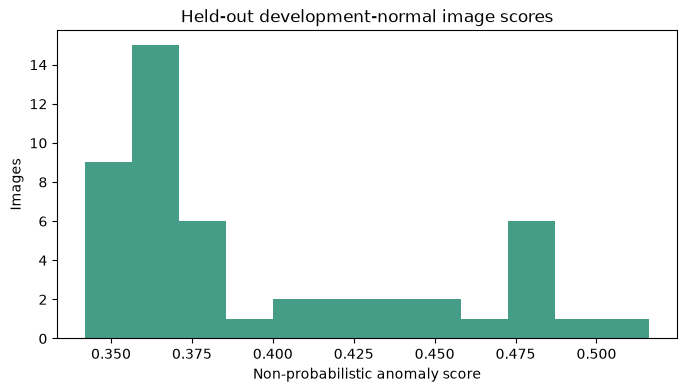

FROZEN before test evaluation — threshold = 0.490511 (97.5% development-normal quantile)


In [7]:
development_scores, development_maps, development_order, dev_extract_seconds, dev_score_seconds = score_paths(development_normal_paths)
development_summary = pd.Series({
    'count': len(development_scores), 'min': development_scores.min(), 'median': np.median(development_scores),
    'p90': np.quantile(development_scores, 0.90), 'p95': np.quantile(development_scores, 0.95),
    'p97.5': np.quantile(development_scores, 0.975), 'p99': np.quantile(development_scores, 0.99), 'max': development_scores.max(),
})
display(development_summary.to_frame('development_normal_score'))
fig, ax = plt.subplots(figsize=(8, 4)); ax.hist(development_scores, bins=12, color='#16856b', alpha=.8);
ax.set(title='Held-out development-normal image scores', xlabel='Non-probabilistic anomaly score', ylabel='Images'); plt.show()

THRESHOLD_QUANTILE = 0.975
FROZEN_THRESHOLD = float(np.quantile(development_scores, THRESHOLD_QUANTILE))
print(f'FROZEN before test evaluation — threshold = {FROZEN_THRESHOLD:.6f} ({THRESHOLD_QUANTILE:.1%} development-normal quantile)')

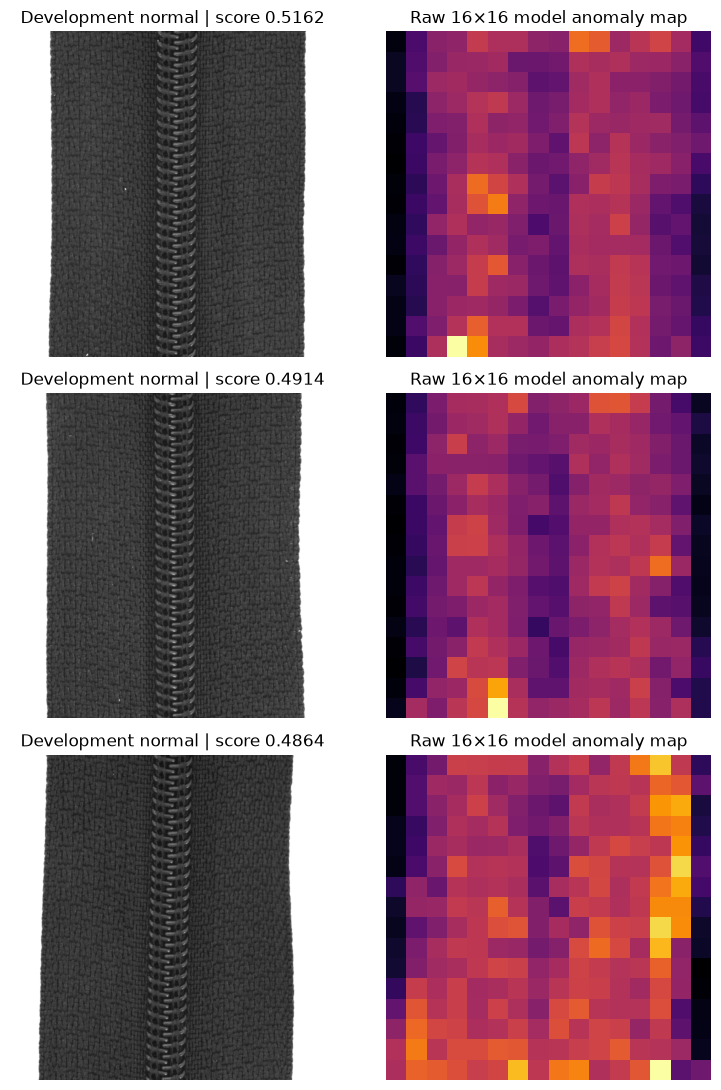

In [8]:
highest_dev = np.argsort(development_scores)[-3:][::-1]
fig, axes = plt.subplots(3, 2, figsize=(8, 11))
for row, index in enumerate(highest_dev):
    with Image.open(development_order[index]) as image: rgb = np.asarray(image.convert('RGB'))
    axes[row, 0].imshow(rgb); axes[row, 0].set_title(f'Development normal | score {development_scores[index]:.4f}')
    axes[row, 1].imshow(development_maps[index], cmap='inferno'); axes[row, 1].set_title('Raw 16×16 model anomaly map')
    for axis in axes[row]: axis.axis('off')
plt.tight_layout(); plt.show()

## 7. One-Time Official Test Evaluation

All configuration above is now frozen. Only here are official test paths and image labels assembled: `test/good` is normal and every defect-subtype directory is anomalous. No decision is changed after these results are observed.

In [9]:
test_paths = test_good_paths + test_anomaly_paths
test_labels = np.array([0] * len(test_good_paths) + [1] * len(test_anomaly_paths), dtype=np.uint8)
test_subtypes = ['good'] * len(test_good_paths) + [path.parent.name for path in test_anomaly_paths]
test_scores, test_maps, test_order, test_extract_seconds, test_score_seconds = score_paths(test_paths)
test_predictions = (test_scores > FROZEN_THRESHOLD).astype(np.uint8)
image_metrics = pd.Series({
    'ROC-AUC': roc_auc_score(test_labels, test_scores), 'Average Precision': average_precision_score(test_labels, test_scores),
    'Precision': precision_score(test_labels, test_predictions, zero_division=0),
    'Recall': recall_score(test_labels, test_predictions, zero_division=0),
    'F1': f1_score(test_labels, test_predictions, zero_division=0),
    'Accuracy (secondary)': float((test_labels == test_predictions).mean()),
})
display(image_metrics.to_frame('value'))
cm = confusion_matrix(test_labels, test_predictions, labels=[0, 1])
pd.DataFrame(cm, index=['Actual normal', 'Actual anomalous'], columns=['Predicted normal', 'Predicted anomalous'])

,value
ROC-AUC,0.927784
Average Precision,0.977740
Precision,0.970000
Recall,0.815126
F1,0.885845
Accuracy (secondary),0.834437


,Predicted normal,Predicted anomalous
Actual normal,29,3
Actual anomalous,22,97


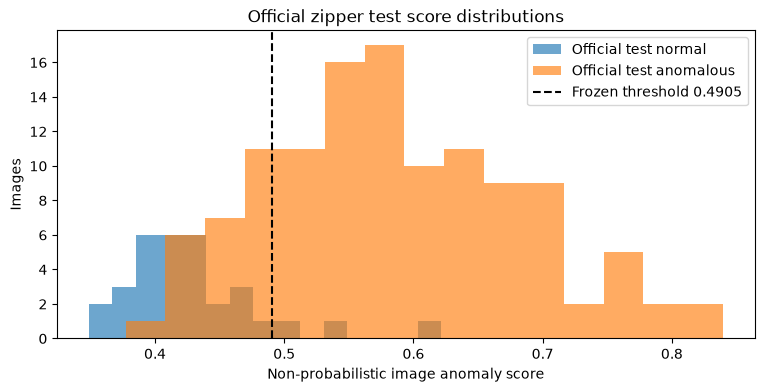

{'test_normal_range': (0.3488304217656453, 0.6215526660283407), 'test_anomalous_range': (0.37730299433072406, 0.8395354151725769)}


In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(test_scores[test_labels == 0], bins=15, alpha=.65, label='Official test normal')
ax.hist(test_scores[test_labels == 1], bins=15, alpha=.65, label='Official test anomalous')
ax.axvline(FROZEN_THRESHOLD, color='black', linestyle='--', label=f'Frozen threshold {FROZEN_THRESHOLD:.4f}')
ax.set(xlabel='Non-probabilistic image anomaly score', ylabel='Images', title='Official zipper test score distributions'); ax.legend(); plt.show()
print({'test_normal_range': (float(test_scores[test_labels == 0].min()), float(test_scores[test_labels == 0].max())),
       'test_anomalous_range': (float(test_scores[test_labels == 1].min()), float(test_scores[test_labels == 1].max()))})

## 8. Defect-Subtype Diagnostics

Subtype results are descriptive only. Detection-rate and score differences identify representation challenges but do not trigger baseline changes.

In [11]:
test_results = pd.DataFrame({'path': test_order, 'label': test_labels, 'subtype': test_subtypes, 'score': test_scores, 'prediction': test_predictions})
subtype_results = (test_results[test_results.label == 1].groupby('subtype').agg(
    image_count=('score', 'size'), min_score=('score', 'min'), median_score=('score', 'median'),
    mean_score=('score', 'mean'), max_score=('score', 'max'), detection_rate=('prediction', 'mean')).sort_values('detection_rate'))
subtype_results.style.format({'min_score': '{:.4f}', 'median_score': '{:.4f}', 'mean_score': '{:.4f}', 'max_score': '{:.4f}', 'detection_rate': '{:.1%}'})

,image_count,min_score,median_score,mean_score,max_score,detection_rate
subtype,,,,,,
split_teeth,18,0.4277,0.5037,0.5190,0.6972,55.6%
broken_teeth,19,0.3773,0.5477,0.5576,0.8095,68.4%
squeezed_teeth,16,0.4127,0.5234,0.5236,0.6682,75.0%
combined,16,0.4733,0.6345,0.6344,0.8015,87.5%
fabric_interior,16,0.4443,0.6086,0.5988,0.7041,93.8%
rough,17,0.4631,0.5512,0.5604,0.6362,94.1%
fabric_border,17,0.5641,0.7115,0.7021,0.8395,100.0%


## 9. Image-Space Maps and Localization Evaluation

Bilinear interpolation expands each raw 16×16 scoring map to the 256×256 evaluation/display grid. It creates no new localization evidence; it only smooths and resamples existing patch scores. Official masks are loaded only now, after the representation, aggregation, memory, and threshold are frozen.

In [12]:
def upsample_maps(raw_maps):
    tensor = torch.from_numpy(raw_maps[:, None])
    return F.interpolate(tensor, size=(INPUT_SIZE, INPUT_SIZE), mode='bilinear', align_corners=False)[:, 0].numpy()

display_maps = upsample_maps(test_maps)
pixel_labels, pixel_scores = [], []
for index, path in enumerate(test_order):
    if path.parent.name == 'good': mask = np.zeros((INPUT_SIZE, INPUT_SIZE), dtype=np.uint8)
    else:
        mask_path = CATEGORY_ROOT / 'ground_truth' / path.parent.name / f'{path.stem}_mask.png'
        with Image.open(mask_path) as source_mask:
            mask = np.asarray(source_mask.convert('L').resize((INPUT_SIZE, INPUT_SIZE), Image.Resampling.NEAREST)) > 0
    pixel_labels.append(mask.reshape(-1)); pixel_scores.append(display_maps[index].reshape(-1))
pixel_labels = np.concatenate(pixel_labels).astype(np.uint8)
pixel_scores = np.concatenate(pixel_scores).astype(np.float32)
pixel_roc_auc = roc_auc_score(pixel_labels, pixel_scores)
pixel_average_precision = average_precision_score(pixel_labels, pixel_scores)
pd.Series({'Pixel ROC-AUC': pixel_roc_auc, 'Pixel Average Precision': pixel_average_precision,
           'Positive pixel prevalence': pixel_labels.mean()}).to_frame('value')

,value
Pixel ROC-AUC,0.963862
Pixel Average Precision,0.501250
Positive pixel prevalence,0.020690


**PRO/AUPRO is not implemented.** A correct benchmark implementation requires connected-region overlap, false-positive-rate integration, and explicit integration limits. An approximation would not be labeled as official AUPRO, so this baseline reports reproducible pixel ROC-AUC and pixel Average Precision instead.

## 10. Qualitative Results

Rows are selected deterministically from frozen results: lowest-scoring test normal, highest-scoring anomaly, lowest-scoring anomaly (hard example), plus a normal above threshold and anomaly below threshold when present. Columns explicitly separate the official **GROUND-TRUTH ANNOTATION** from the **MODEL ANOMALY MAP**.

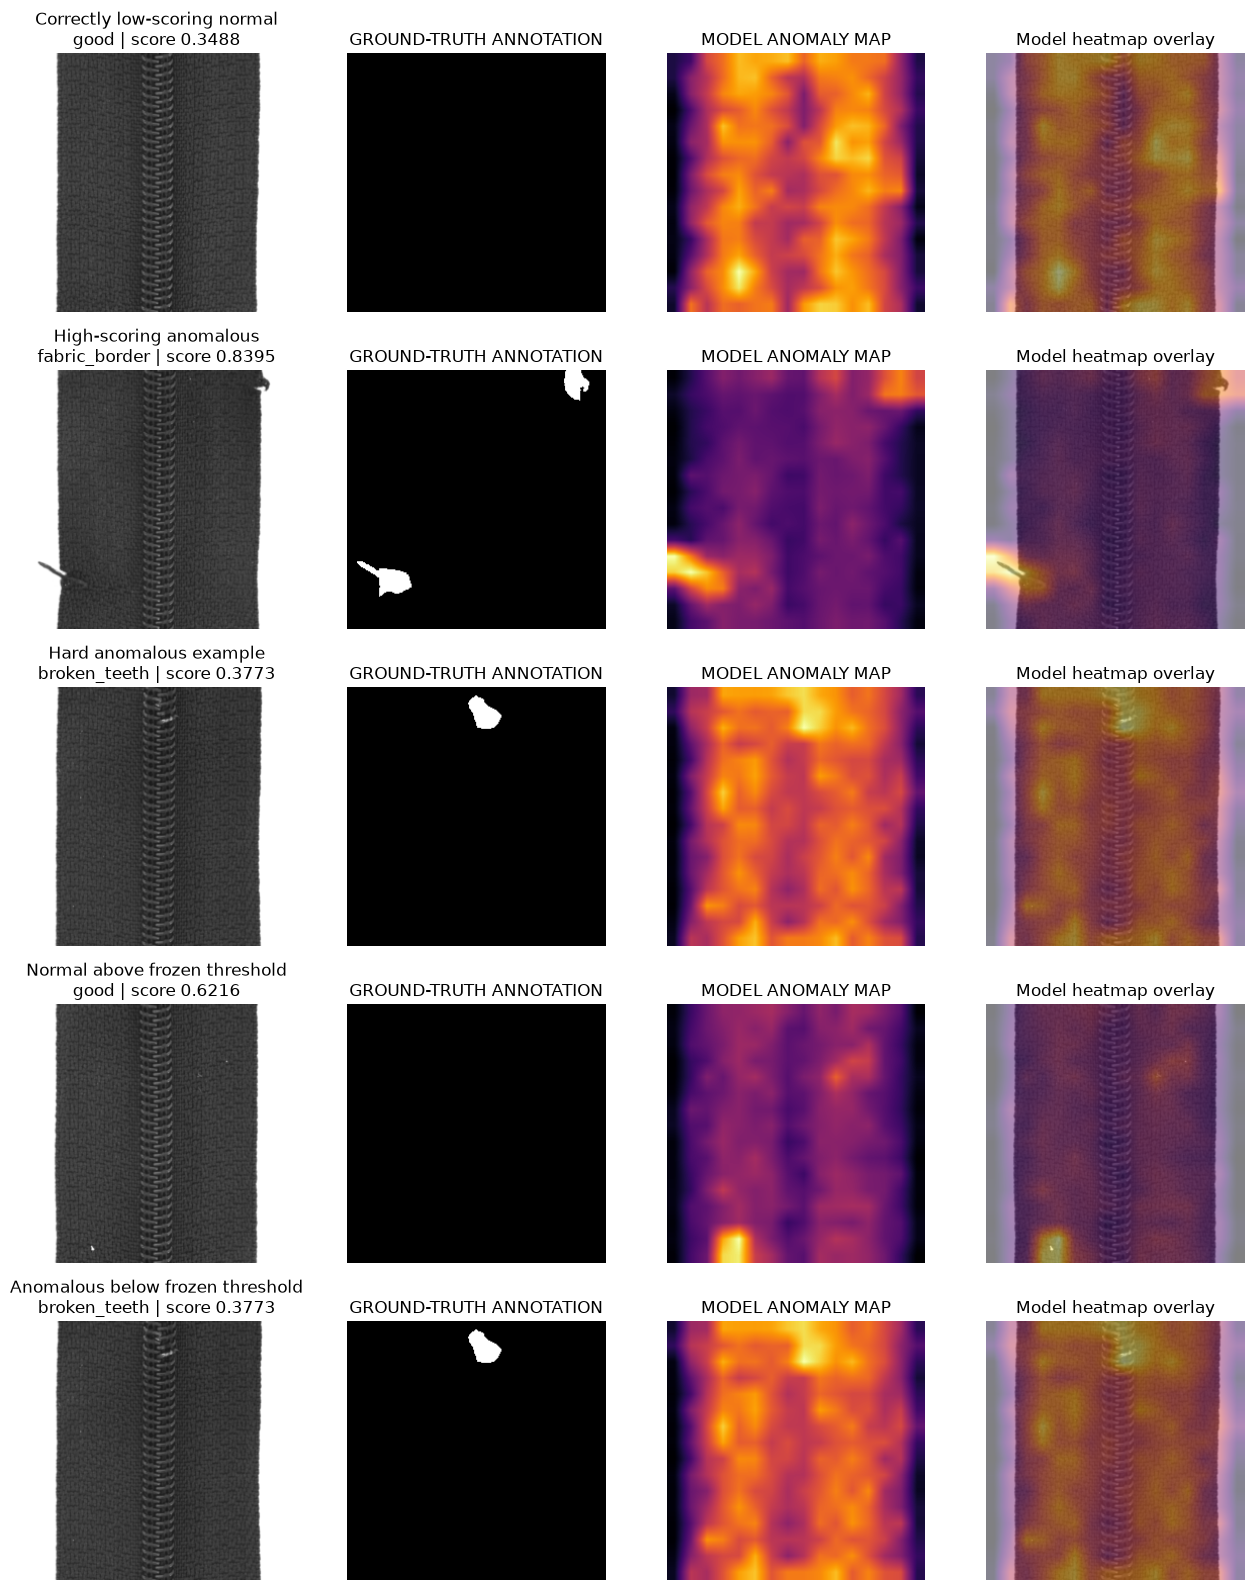

In [13]:
normal_indices = np.flatnonzero(test_labels == 0); anomaly_indices = np.flatnonzero(test_labels == 1)
selected = [('Correctly low-scoring normal', normal_indices[np.argmin(test_scores[normal_indices])]),
            ('High-scoring anomalous', anomaly_indices[np.argmax(test_scores[anomaly_indices])]),
            ('Hard anomalous example', anomaly_indices[np.argmin(test_scores[anomaly_indices])])]
false_positive_indices = np.flatnonzero((test_labels == 0) & (test_predictions == 1))
false_negative_indices = np.flatnonzero((test_labels == 1) & (test_predictions == 0))
if len(false_positive_indices): selected.append(('Normal above frozen threshold', false_positive_indices[np.argmax(test_scores[false_positive_indices])]))
if len(false_negative_indices): selected.append(('Anomalous below frozen threshold', false_negative_indices[np.argmin(test_scores[false_negative_indices])]))

fig, axes = plt.subplots(len(selected), 4, figsize=(13, 3.2 * len(selected)))
for row, (description, index) in enumerate(selected):
    path = test_order[index]
    with Image.open(path) as source_image: image = np.asarray(source_image.convert('RGB').resize((INPUT_SIZE, INPUT_SIZE), Image.Resampling.BILINEAR))
    if test_labels[index]:
        mask_path = CATEGORY_ROOT / 'ground_truth' / path.parent.name / f'{path.stem}_mask.png'
        with Image.open(mask_path) as source_mask: mask = np.asarray(source_mask.convert('L').resize((INPUT_SIZE, INPUT_SIZE), Image.Resampling.NEAREST)) > 0
    else: mask = np.zeros((INPUT_SIZE, INPUT_SIZE), dtype=bool)
    anomaly_map = display_maps[index]
    axes[row, 0].imshow(image); axes[row, 0].set_title(f'{description}\n{path.parent.name} | score {test_scores[index]:.4f}')
    axes[row, 1].imshow(mask, cmap='gray', vmin=0, vmax=1); axes[row, 1].set_title('GROUND-TRUTH ANNOTATION')
    axes[row, 2].imshow(anomaly_map, cmap='inferno'); axes[row, 2].set_title('MODEL ANOMALY MAP')
    axes[row, 3].imshow(image); axes[row, 3].imshow(anomaly_map, cmap='inferno', alpha=.50); axes[row, 3].set_title('Model heatmap overlay')
    for axis in axes[row]: axis.axis('off')
plt.tight_layout(); plt.show()

## 11. Baseline Failure Analysis

False positives and false negatives below are observations under the frozen normal-only threshold. Plausible contributors include the 16×16 scoring grid, 256-pixel resize, generic ImageNet representation, random normal-memory reduction, and top-patch aggregation. These are hypotheses—not proven causes. Diffuse maps may reflect normal structural variation as well as representation mismatch; small masks may be attenuated by resizing or pooling.

In [14]:
tn, fp, fn, tp = cm.ravel()
failure_summary = pd.Series({
    'true_normals': int(tn), 'false_positives': int(fp), 'false_negatives': int(fn), 'true_anomalies': int(tp),
    'normal_above_boundary_pct': fp / (tn + fp) * 100, 'anomalous_below_boundary_pct': fn / (fn + tp) * 100,
})
display(failure_summary.to_frame('value'))
print('Lowest-detection subtypes (diagnostic only):')
display(subtype_results.head(3).style.format({'min_score': '{:.4f}', 'median_score': '{:.4f}', 'mean_score': '{:.4f}', 'max_score': '{:.4f}', 'detection_rate': '{:.1%}'}))

,value
true_normals,29.000000
false_positives,3.000000
false_negatives,22.000000
true_anomalies,97.000000
normal_above_boundary_pct,9.375000
anomalous_below_boundary_pct,18.487395


Lowest-detection subtypes (diagnostic only):


,image_count,min_score,median_score,mean_score,max_score,detection_rate
subtype,,,,,,
split_teeth,18,0.4277,0.5037,0.5190,0.6972,55.6%
broken_teeth,19,0.3773,0.5477,0.5576,0.8095,68.4%
squeezed_teeth,16,0.4127,0.5234,0.5236,0.6682,75.0%


## 12. Baseline Limitations

- One MVTec AD category; no external or factory validation.
- ImageNet domain mismatch and no learned industrial representation.
- Frozen generic CNN features with no fine-tuning.
- Simple nearest-reference memory and random reduction, not PatchCore coreset optimization.
- Sensitivity to 256×256 resize and 16×16 feature-map resolution.
- Only 48 held-out development-normal images support the threshold.
- Threshold uses normal scores only and cannot directly optimize anomaly recall.
- Dataset-specific evaluation and MVTec AD CC BY-NC-SA restrictions.
- Anomaly scores are not probabilities; maps are not causal explanations or diagnoses.
- Interpolated maps add display resolution, not localization information.

## 13. PatchCore Comparison Readiness

Frozen for comparison:

- Category: zipper; split seed 42; 192 reference / 48 development-normal images.
- Preprocessing: deterministic 256×256 bilinear antialiased resize, RGB tensor, ImageNet normalization.
- Backbone: official ImageNet ResNet18 weights, frozen through `layer2`.
- Baseline grid/embedding: pooled 16×16 grid, 128 dimensions.
- Image score: mean of highest 1% of patch distances, minimum three patches.
- Threshold: 97.5th empirical quantile of held-out development-normal image scores.
- Test labels: `good=0`, every zipper defect subtype `=1`.
- Metrics: image ROC-AUC/AP and threshold metrics; pixel ROC-AUC/AP.

Notebook 16 should replace random memory reduction and single-layer patch handling with PatchCore multi-layer embeddings, principled coreset selection, and its documented scoring/reweighting while preserving the split, preprocessing study boundary, threshold-development isolation, labels, and metrics wherever technically comparable.

In [15]:
runtime_summary = pd.Series({
    'reference_feature_extraction_seconds': reference_extract_seconds,
    'development_feature_extraction_seconds': dev_extract_seconds, 'development_nn_scoring_seconds': dev_score_seconds,
    'test_feature_extraction_seconds': test_extract_seconds, 'test_nn_scoring_seconds': test_score_seconds,
    'evaluated_test_images': len(test_paths), 'stored_reference_memory_mb': reference_memory.nbytes / 1024**2,
})
runtime_summary.to_frame('value')

,value
reference_feature_extraction_seconds,4.714504
development_feature_extraction_seconds,0.824051
development_nn_scoring_seconds,0.297251
test_feature_extraction_seconds,2.586496
test_nn_scoring_seconds,0.655926
evaluated_test_images,151.000000
stored_reference_memory_mb,2.441406


## Visual Anomaly Baseline Conclusions

This notebook provides a reproducible normal-only zipper baseline with a frozen generic backbone, bounded nearest-patch reference memory, frozen development-normal threshold, one-time official image-level evaluation, and evaluation-only mask usage. Results should be treated as the baseline to beat—not as a production-quality inspection model. No model artifact is selected or exported.